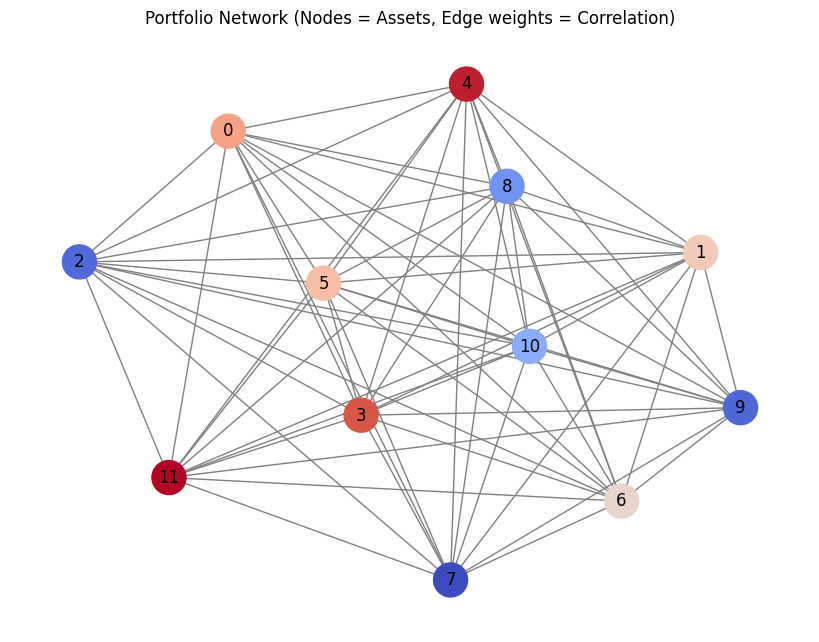

Shocked node: 0
Asset 0: value = 70.00
Asset 1: value = 90.40
Asset 2: value = 73.04
Asset 3: value = 83.82
Asset 4: value = 82.15
Asset 5: value = 76.25
Asset 6: value = 94.68
Asset 7: value = 96.94
Asset 8: value = 85.53
Asset 9: value = 83.74
Asset 10: value = 87.22
Asset 11: value = 89.28


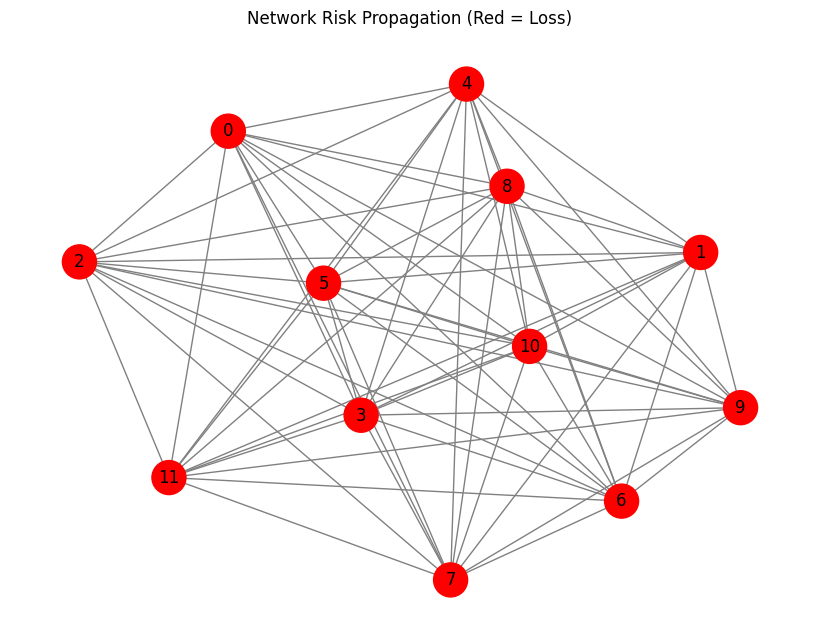

Asset 0: final value = 18.41
Asset 1: final value = 13.28
Asset 2: final value = 23.25
Asset 3: final value = 16.12
Asset 4: final value = 23.62
Asset 5: final value = 13.24
Asset 6: final value = 11.18
Asset 7: final value = 17.23
Asset 8: final value = 35.50
Asset 9: final value = 19.94
Asset 10: final value = 9.86
Asset 11: final value = 21.64


In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

num_assets = 12
G = nx.Graph()

# Add nodes with initial value
for i in range(num_assets):
    G.add_node(i, value=100, risk_weight=random.uniform(0.5,2))  # starting value + importance

# Add random edges (correlations)
for i in range(num_assets):
    for j in range(i+1, num_assets):
        corr = np.random.rand()*0.8 + 0.1  # 0.1 to 0.9 correlation
        G.add_edge(i, j, weight=corr)

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
node_colors = [G.nodes[n]['risk_weight'] for n in G.nodes]
nx.draw(G, pos, with_labels=True, node_color=node_colors, cmap='coolwarm', node_size=600, edge_color='gray')
plt.title("Portfolio Network (Nodes = Assets, Edge weights = Correlation)")
plt.show()

shocked_node = random.randint(0, num_assets-1)
initial_loss_fraction = 0.3
G.nodes[shocked_node]['value'] *= (1 - initial_loss_fraction)

# Propagate losses to neighbors
for neighbor in G.neighbors(shocked_node):
    weight = G.edges[shocked_node, neighbor]['weight']
    G.nodes[neighbor]['value'] *= (1 - initial_loss_fraction * weight)

print(f"Shocked node: {shocked_node}")
for n in G.nodes:
    print(f"Asset {n}: value = {G.nodes[n]['value']:.2f}")

    values = [G.nodes[n]['value'] for n in G.nodes]
colors = ['red' if v<100 else 'green' for v in values]

plt.figure(figsize=(8,6))
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=600, edge_color='gray')
plt.title("Network Risk Propagation (Red = Loss)")
plt.show()
rounds = 5
shocks = [random.randint(0, num_assets-1) for _ in range(3)]
loss_fraction = 0.2

for r in range(rounds):
    for s in shocks:
        G.nodes[s]['value'] *= (1 - loss_fraction)
        for neighbor in G.neighbors(s):
            weight = G.edges[s, neighbor]['weight']
            G.nodes[neighbor]['value'] *= (1 - loss_fraction * weight)

# Final values
for n in G.nodes:
    print(f"Asset {n}: final value = {G.nodes[n]['value']:.2f}")